# Charlotte Regional Explorer: Broadband Integration Analysis

This notebook integrates FCC broadband availability data with the Charlotte Regional Explorer's American Community Survey (ACS) demographic data.

## Objectives:
- Load and analyze broadband data from NC and SC
- Process geographic relationships between Census tracts and places
- Integrate internet speed metrics with existing regional explorer data
- Create analysis-ready dataset for the mapping application

## 1. Import Required Libraries

Import all necessary libraries for data processing, geographic analysis, and visualization.

In [ ]:
# Core data processing libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.3


## 2. Load Broadband Data

Load the FCC broadband data for both North Carolina and South Carolina.

In [4]:
# Define file paths
nc_broadband_path = 'Data/NC_broadband/bdc_37_fixed_broadband_summary_by_geography_place_D24_16sep2025.csv'
sc_broadband_path = 'Data/SC_broadband/bdc_45_fixed_broadband_summary_by_geography_place_D24_16sep2025.csv'

# Load broadband data
print("Loading broadband data...")
nc_broadband = pd.read_csv(nc_broadband_path)
sc_broadband = pd.read_csv(sc_broadband_path)

print(f"NC Broadband data shape: {nc_broadband.shape}")
print(f"SC Broadband data shape: {sc_broadband.shape}")

# Display column names
print("\nColumn names:")
print(nc_broadband.columns.tolist())

Loading broadband data...
NC Broadband data shape: (79410, 14)
SC Broadband data shape: (47400, 14)

Column names:
['area_data_type', 'geography_type', 'geography_id', 'geography_desc', 'geography_desc_full', 'total_units', 'biz_res', 'technology', 'speed_02_02', 'speed_10_1', 'speed_25_3', 'speed_100_20', 'speed_250_25', 'speed_1000_100']


## 3. Explore Broadband Data Structure

Examine the structure and content of the broadband datasets.

In [5]:
# Combine both states for analysis
broadband_combined = pd.concat([nc_broadband, sc_broadband], ignore_index=True)

print("Combined broadband data shape:", broadband_combined.shape)
print("\nUnique values in key columns:")
print(f"Business/Residential types: {broadband_combined['biz_res'].unique()}")
print(f"\nTechnology types: {broadband_combined['technology'].unique()}")
print(f"\nGeography types: {broadband_combined['geography_type'].unique()}")

# Display sample data
print("\nSample broadband data:")
display(broadband_combined.head(3))

Combined broadband data shape: (126810, 14)

Unique values in key columns:
Business/Residential types: ['R' 'B']

Technology types: ['Any Technology' 'All Wired' 'Any Terrestrial'
 'All Wired and Licensed Fixed Wireless' 'Copper' 'Cable/Fiber' 'Cable'
 'Fiber' 'All Satellite' 'GSO Satellite' 'NGSO Satellite'
 'All Fixed Wireless' 'Unlicensed Fixed Wireless'
 'Licensed Fixed Wireless' 'Other']

Geography types: ['Census Place']

Sample broadband data:


,area_data_type,geography_type,geography_id,geography_desc,geography_desc_full,total_units,biz_res,technology,speed_02_02,speed_10_1,speed_25_3,speed_100_20,speed_250_25,speed_1000_100
0,Total,Census Place,3700160,Aberdeen,"Aberdeen, NC",5349,R,Any Technology,1.000000,1.000000,1.00000,1.000000,0.947841,0.192185
1,Total,Census Place,3700160,Aberdeen,"Aberdeen, NC",5349,B,Any Technology,1.000000,1.000000,1.00000,1.000000,0.301552,0.192372
2,Total,Census Place,3700160,Aberdeen,"Aberdeen, NC",5349,R,All Wired,0.975696,0.974949,0.96934,0.957936,0.947841,0.192185


## 4. Filter and Process Broadband Data

Filter for residential data with "Any Technology" to get the best available speeds for each location.

In [6]:
# Filter for residential, any technology data
broadband_filtered = broadband_combined[
    (broadband_combined['biz_res'] == 'R') &  # Residential only
    (broadband_combined['technology'] == 'Any Technology')  # Best available technology
].copy()

print(f"Filtered broadband data shape: {broadband_filtered.shape}")

# Select relevant columns for integration
broadband_clean = broadband_filtered[[
    'geography_id', 'geography_desc', 'geography_desc_full', 'total_units',
    'speed_25_3', 'speed_100_20', 'speed_250_25', 'speed_1000_100'
]].copy()

# Rename columns for clarity
broadband_clean.columns = [
    'place_geoid', 'place_name', 'place_full_name', 'total_housing_units',
    'pct_25mbps_3mbps', 'pct_100mbps_20mbps', 'pct_250mbps_25mbps', 'pct_1gbps_100mbps'
]

# Convert percentages to actual percentages (multiply by 100)
speed_cols = ['pct_25mbps_3mbps', 'pct_100mbps_20mbps', 'pct_250mbps_25mbps', 'pct_1gbps_100mbps']
for col in speed_cols:
    broadband_clean[col] = broadband_clean[col] * 100

print("\nProcessed broadband data:")
display(broadband_clean.head())

print(f"\nUnique places: {broadband_clean['place_geoid'].nunique()}")

Filtered broadband data shape: (4227, 14)

Processed broadband data:


,place_geoid,place_name,place_full_name,total_housing_units,pct_25mbps_3mbps,pct_100mbps_20mbps,pct_250mbps_25mbps,pct_1gbps_100mbps
0,3700160,Aberdeen,"Aberdeen, NC",5349,100.0,100.0,94.784072,19.218546
30,3700440,Advance,"Advance, NC",768,100.0,100.0,100.000000,100.000000
60,3700500,Ahoskie,"Ahoskie, NC",2443,100.0,100.0,90.053213,50.716332
90,3700640,Alamance,"Alamance, NC",437,100.0,100.0,98.627002,94.965675
120,3700680,Albemarle,"Albemarle, NC",8501,100.0,100.0,98.588401,65.851076



Unique places: 1251


## 5. Load Regional Explorer Data

Load the existing Charlotte Regional Explorer ACS data to understand its structure.

In [7]:
# Load the most recent ACS data
acs_2023_path = 'Data/CharlotteRegionalExplorerACS_2023.csv'
acs_data = pd.read_csv(acs_2023_path)

print(f"ACS 2023 data shape: {acs_data.shape}")
print("\nACS column names:")
print(acs_data.columns.tolist())

# Display sample ACS data
print("\nSample ACS data:")
display(acs_data[['Year', 'NAME', 'GEOID', 'PercentInternetAccess']].head())

# Analyze GEOID structure
print("\nGEOID analysis:")
print(f"Unique GEOIDs: {acs_data['GEOID'].nunique()}")
print(f"GEOID length distribution:")
print(acs_data['GEOID'].astype(str).str.len().value_counts().sort_index())

ACS 2023 data shape: (752, 22)

ACS column names:
['Year', 'NAME', 'GEOID', 'PercentUnder18', 'PercentOver65', 'PercentAsian', 'PercentBlack', 'PercentWhite', 'PercentHispanic', 'PercentOther', 'PercentDroveMoreThan20Minutes', 'PercentHighSchoolDiploma', 'PercentAdultsWithAtLeastBachelors', 'PercentPrivateSchool', 'PercentDroveAlone', 'PercentVeteran', 'PercentEmployed', 'PercentInternetAccess', 'PercentVacant', 'PercentOccupied', 'PercentOwnerOccupied', 'PercentNoVehicle']

Sample ACS data:


,Year,NAME,GEOID,PercentInternetAccess
0,2023,Census Tract 9201; Anson County; North Carolina,37007920100,75.636943
1,2023,Census Tract 9202; Anson County; North Carolina,37007920200,72.588055
2,2023,Census Tract 9203.01; Anson County; North Caro...,37007920301,67.154930
3,2023,Census Tract 9203.02; Anson County; North Caro...,37007920302,87.772926
4,2023,Census Tract 9204; Anson County; North Carolina,37007920400,50.406504



GEOID analysis:
Unique GEOIDs: 752
GEOID length distribution:
GEOID
11    752
Name: count, dtype: int64


## 6. Geographic Analysis: Tract vs Place Relationship

Analyze the geographic relationship between Census tracts (ACS data) and Census places (broadband data).

In [8]:
# Extract state and county from tract GEOIDs
acs_data['state_fips'] = acs_data['GEOID'].astype(str).str[:2]
acs_data['county_fips'] = acs_data['GEOID'].astype(str).str[:5]
acs_data['tract_fips'] = acs_data['GEOID'].astype(str)

# Analyze geographic distribution
print("State distribution in ACS data:")
print(acs_data['state_fips'].value_counts())

print("\nPlace distribution in broadband data:")
broadband_clean['state_fips'] = broadband_clean['place_geoid'].astype(str).str[:2]
print(broadband_clean['state_fips'].value_counts())

# Show geographic coverage
print("\nNC Counties in ACS data:")
nc_counties_acs = acs_data[acs_data['state_fips'] == '37']['county_fips'].unique()
print(f"Count: {len(nc_counties_acs)}")
print(sorted(nc_counties_acs)[:10])  # Show first 10

print("\nSC Counties in ACS data:")
sc_counties_acs = acs_data[acs_data['state_fips'] == '45']['county_fips'].unique()
print(f"Count: {len(sc_counties_acs)}")
print(sorted(sc_counties_acs))

State distribution in ACS data:
state_fips
37    664
45     88
Name: count, dtype: int64

Place distribution in broadband data:
state_fips
37    2647
45    1580
Name: count, dtype: int64

NC Counties in ACS data:
Count: 11
['37007', '37025', '37035', '37045', '37071', '37097', '37109', '37119', '37159', '37167']

SC Counties in ACS data:
Count: 3
['45023', '45057', '45091']


## 7. Create County-Level Aggregation

Since tract-to-place mapping is complex, we'll aggregate both datasets to county level for initial integration.

In [9]:
# Aggregate ACS data to county level
acs_county = acs_data.groupby(['county_fips']).agg({
    'PercentUnder18': 'mean',
    'PercentOver65': 'mean',
    'PercentAsian': 'mean',
    'PercentBlack': 'mean',
    'PercentWhite': 'mean',
    'PercentHispanic': 'mean',
    'PercentInternetAccess': 'mean',
    'PercentEmployed': 'mean',
    'PercentAdultsWithAtLeastBachelors': 'mean',
    'PercentOwnerOccupied': 'mean'
}).round(2).reset_index()

print(f"County-level ACS data shape: {acs_county.shape}")
display(acs_county.head())

# Create county mapping for places
# This is a simplified approach - in reality, places can span multiple counties
broadband_clean['county_fips'] = broadband_clean['place_geoid'].astype(str).str[:5]

# Aggregate broadband data to county level (weighted by housing units)
def weighted_average(group, values_col, weights_col):
    return np.average(group[values_col], weights=group[weights_col])

broadband_county = broadband_clean.groupby('county_fips').apply(
    lambda x: pd.Series({
        'avg_25mbps_3mbps': weighted_average(x, 'pct_25mbps_3mbps', 'total_housing_units'),
        'avg_100mbps_20mbps': weighted_average(x, 'pct_100mbps_20mbps', 'total_housing_units'),
        'avg_250mbps_25mbps': weighted_average(x, 'pct_250mbps_25mbps', 'total_housing_units'),
        'avg_1gbps_100mbps': weighted_average(x, 'pct_1gbps_100mbps', 'total_housing_units'),
        'total_places': len(x),
        'total_housing_units': x['total_housing_units'].sum()
    })
).round(2).reset_index()

print(f"\nCounty-level broadband data shape: {broadband_county.shape}")
display(broadband_county.head())

County-level ACS data shape: (14, 11)


,county_fips,PercentUnder18,PercentOver65,PercentAsian,PercentBlack,PercentWhite,PercentHispanic,PercentInternetAccess,PercentEmployed,PercentAdultsWithAtLeastBachelors,PercentOwnerOccupied
0,37007,17.31,19.05,1.00,45.23,47.23,3.23,68.66,93.06,11.11,65.93
1,37025,24.28,14.24,4.60,18.41,59.45,12.63,76.24,94.87,34.92,71.86
2,37035,21.68,18.59,4.07,8.49,71.77,11.34,73.15,95.71,25.03,71.67
3,37045,22.40,18.88,0.91,18.47,70.98,4.44,63.55,93.82,21.37,69.83
4,37071,21.80,16.93,1.54,15.47,70.45,8.68,74.36,94.74,25.85,68.15



County-level broadband data shape: (905, 7)


,county_fips,avg_25mbps_3mbps,avg_100mbps_20mbps,avg_250mbps_25mbps,avg_1gbps_100mbps,total_places,total_housing_units
0,37001,100.0,100.0,94.78,19.22,4.0,16047.0
1,37004,100.0,100.0,100.00,100.00,3.0,2304.0
2,37005,100.0,100.0,90.05,50.72,5.0,7329.0
3,37006,100.0,100.0,98.59,67.27,7.0,26814.0
4,37008,100.0,100.0,78.34,0.96,3.0,942.0


## 8. Merge ACS and Broadband Data

Join the county-level ACS demographic data with broadband speed data.

In [10]:
# Merge datasets at county level
merged_data = pd.merge(
    acs_county, 
    broadband_county, 
    on='county_fips', 
    how='inner'
)

print(f"Merged data shape: {merged_data.shape}")
print(f"Counties with both ACS and broadband data: {len(merged_data)}")

# Add county name information
county_names = acs_data.groupby('county_fips')['NAME'].first().str.extract(r'; ([^;]+);')[0].reset_index()
county_names.columns = ['county_fips', 'county_name']

merged_data = pd.merge(merged_data, county_names, on='county_fips', how='left')

print("\nMerged dataset sample:")
display(merged_data[['county_fips', 'county_name', 'PercentInternetAccess', 'avg_100mbps_20mbps']].head(10))

Merged data shape: (8, 17)
Counties with both ACS and broadband data: 8

Merged dataset sample:


,county_fips,county_name,PercentInternetAccess,avg_100mbps_20mbps
0,37025,Cabarrus County,76.24,100.0
1,37035,Catawba County,73.15,100.0
2,37045,Cleveland County,63.55,100.0
3,37071,Gaston County,74.36,100.0
4,37097,Iredell County,78.23,100.0
5,37109,Lincoln County,77.13,100.0
6,37167,Stanly County,69.18,100.0
7,45057,Lancaster County,70.65,100.0


## 9. Data Analysis: Internet Access vs Broadband Speeds

Analyze the relationship between existing internet access percentages and new broadband speed data.

In [11]:
# Calculate correlation between internet access and broadband speeds
speed_cols = ['avg_25mbps_3mbps', 'avg_100mbps_20mbps', 'avg_250mbps_25mbps', 'avg_1gbps_100mbps']

print("Correlation between PercentInternetAccess and broadband speeds:")
for col in speed_cols:
    corr = merged_data['PercentInternetAccess'].corr(merged_data[col])
    print(f"{col}: {corr:.3f}")

# Create summary statistics
print("\nBroadband speed statistics:")
display(merged_data[speed_cols].describe())

print("\nCounties with highest 100/20 Mbps coverage:")
top_broadband = merged_data.nlargest(5, 'avg_100mbps_20mbps')[['county_name', 'avg_100mbps_20mbps', 'PercentInternetAccess']]
display(top_broadband)

print("\nCounties with lowest 100/20 Mbps coverage:")
low_broadband = merged_data.nsmallest(5, 'avg_100mbps_20mbps')[['county_name', 'avg_100mbps_20mbps', 'PercentInternetAccess']]
display(low_broadband)

Correlation between PercentInternetAccess and broadband speeds:
avg_25mbps_3mbps: nan
avg_100mbps_20mbps: nan
avg_250mbps_25mbps: -0.605
avg_1gbps_100mbps: -0.681

Broadband speed statistics:


,avg_25mbps_3mbps,avg_100mbps_20mbps,avg_250mbps_25mbps,avg_1gbps_100mbps
count,8.0,8.0,8.000000,8.000000
mean,100.0,100.0,95.077500,62.575000
std,0.0,0.0,4.667284,36.815541
min,100.0,100.0,85.390000,1.120000
25%,100.0,100.0,94.117500,50.932500
50%,100.0,100.0,95.025000,69.255000
75%,100.0,100.0,98.257500,91.640000
max,100.0,100.0,100.000000,99.680000



Counties with highest 100/20 Mbps coverage:


,county_name,avg_100mbps_20mbps,PercentInternetAccess
0,Cabarrus County,100.0,76.24
1,Catawba County,100.0,73.15
2,Cleveland County,100.0,63.55
3,Gaston County,100.0,74.36
4,Iredell County,100.0,78.23



Counties with lowest 100/20 Mbps coverage:


,county_name,avg_100mbps_20mbps,PercentInternetAccess
0,Cabarrus County,100.0,76.24
1,Catawba County,100.0,73.15
2,Cleveland County,100.0,63.55
3,Gaston County,100.0,74.36
4,Iredell County,100.0,78.23


## 10. Visualization: Broadband Speed Distribution

Create visualizations to understand broadband speed patterns across the Charlotte region.

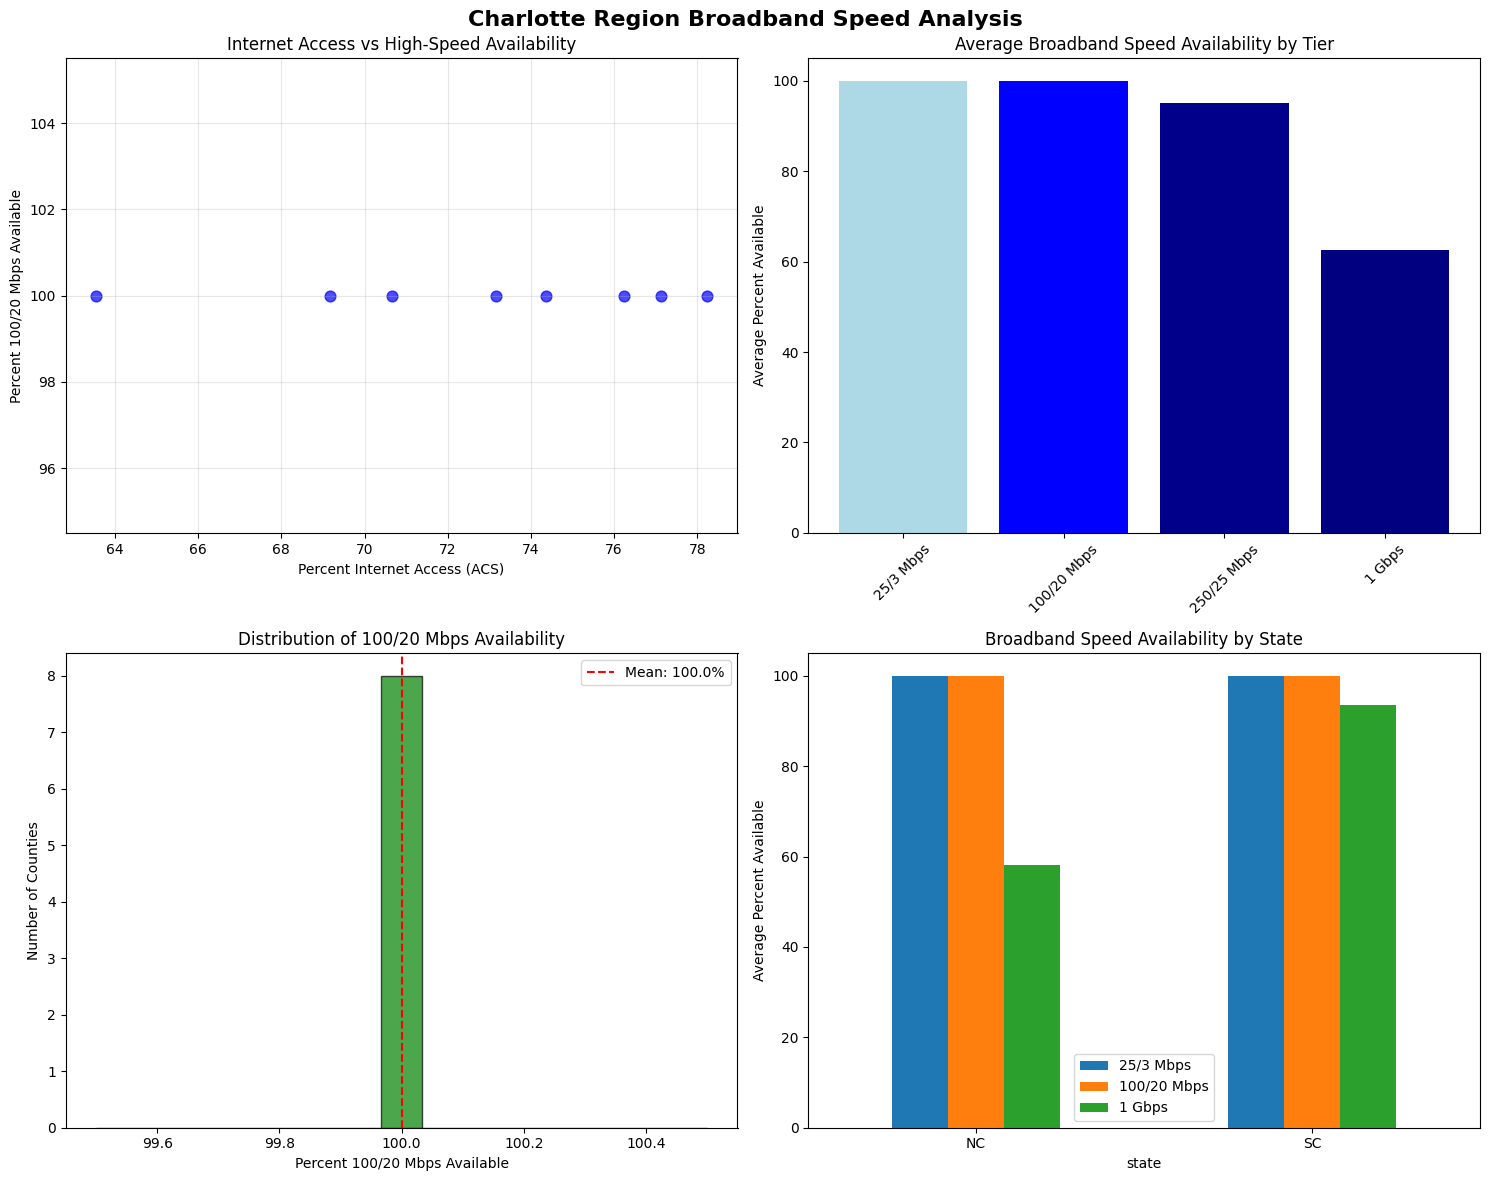


State-level broadband summary:


,avg_25mbps_3mbps,avg_100mbps_20mbps,avg_1gbps_100mbps
state,,,
NC,100.0,100.0,58.1
SC,100.0,100.0,93.6


In [12]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Charlotte Region Broadband Speed Analysis', fontsize=16, fontweight='bold')

# Plot 1: Internet Access vs 100/20 Mbps availability
axes[0, 0].scatter(merged_data['PercentInternetAccess'], merged_data['avg_100mbps_20mbps'], 
                   alpha=0.7, s=60, color='blue')
axes[0, 0].set_xlabel('Percent Internet Access (ACS)')
axes[0, 0].set_ylabel('Percent 100/20 Mbps Available')
axes[0, 0].set_title('Internet Access vs High-Speed Availability')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Speed tier comparison
speed_comparison = merged_data[['avg_25mbps_3mbps', 'avg_100mbps_20mbps', 'avg_250mbps_25mbps', 'avg_1gbps_100mbps']].mean()
axes[0, 1].bar(range(len(speed_comparison)), speed_comparison.values, 
               color=['lightblue', 'blue', 'darkblue', 'navy'])
axes[0, 1].set_xticks(range(len(speed_comparison)))
axes[0, 1].set_xticklabels(['25/3 Mbps', '100/20 Mbps', '250/25 Mbps', '1 Gbps'], rotation=45)
axes[0, 1].set_ylabel('Average Percent Available')
axes[0, 1].set_title('Average Broadband Speed Availability by Tier')

# Plot 3: Distribution of 100/20 Mbps speeds
axes[1, 0].hist(merged_data['avg_100mbps_20mbps'], bins=15, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].set_xlabel('Percent 100/20 Mbps Available')
axes[1, 0].set_ylabel('Number of Counties')
axes[1, 0].set_title('Distribution of 100/20 Mbps Availability')
axes[1, 0].axvline(merged_data['avg_100mbps_20mbps'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {merged_data["avg_100mbps_20mbps"].mean():.1f}%')
axes[1, 0].legend()

# Plot 4: State comparison
merged_data['state'] = merged_data['county_fips'].str[:2].map({'37': 'NC', '45': 'SC'})
state_comparison = merged_data.groupby('state')[['avg_25mbps_3mbps', 'avg_100mbps_20mbps', 'avg_1gbps_100mbps']].mean()
state_comparison.plot(kind='bar', ax=axes[1, 1], rot=0)
axes[1, 1].set_title('Broadband Speed Availability by State')
axes[1, 1].set_ylabel('Average Percent Available')
axes[1, 1].legend(['25/3 Mbps', '100/20 Mbps', '1 Gbps'])

plt.tight_layout()
plt.show()

# Print state-level summary
print("\nState-level broadband summary:")
display(state_comparison.round(1))

## 11. Prepare Data for Regional Explorer Integration

Create the final dataset structure for integration with your regional explorer application.

In [13]:
# Create final dataset for regional explorer
regional_explorer_enhanced = merged_data.copy()

# Add broadband categories for easier analysis
regional_explorer_enhanced['broadband_basic'] = regional_explorer_enhanced['avg_25mbps_3mbps']
regional_explorer_enhanced['broadband_good'] = regional_explorer_enhanced['avg_100mbps_20mbps']
regional_explorer_enhanced['broadband_excellent'] = regional_explorer_enhanced['avg_250mbps_25mbps']
regional_explorer_enhanced['broadband_gigabit'] = regional_explorer_enhanced['avg_1gbps_100mbps']

# Create broadband quality score (weighted average)
regional_explorer_enhanced['broadband_quality_score'] = (
    (regional_explorer_enhanced['broadband_basic'] * 0.1) +
    (regional_explorer_enhanced['broadband_good'] * 0.3) +
    (regional_explorer_enhanced['broadband_excellent'] * 0.4) +
    (regional_explorer_enhanced['broadband_gigabit'] * 0.2)
).round(2)

# Select final columns
final_columns = [
    'county_fips', 'county_name', 'state',
    'PercentInternetAccess', 'PercentEmployed', 'PercentAdultsWithAtLeastBachelors',
    'PercentUnder18', 'PercentOver65', 'PercentWhite', 'PercentBlack', 'PercentHispanic',
    'broadband_basic', 'broadband_good', 'broadband_excellent', 'broadband_gigabit',
    'broadband_quality_score', 'total_places', 'total_housing_units'
]

final_dataset = regional_explorer_enhanced[final_columns].copy()

print(f"Final dataset shape: {final_dataset.shape}")
print("\nFinal dataset sample:")
display(final_dataset.head())

# Save the enhanced dataset
output_path = 'Data/charlotte_regional_explorer_with_broadband.csv'
final_dataset.to_csv(output_path, index=False)
print(f"\nEnhanced dataset saved to: {output_path}")

Final dataset shape: (8, 18)

Final dataset sample:


,county_fips,county_name,state,PercentInternetAccess,PercentEmployed,PercentAdultsWithAtLeastBachelors,PercentUnder18,PercentOver65,PercentWhite,PercentBlack,PercentHispanic,broadband_basic,broadband_good,broadband_excellent,broadband_gigabit,broadband_quality_score,total_places,total_housing_units
0,37025,Cabarrus County,NC,76.24,94.87,34.92,24.28,14.24,59.45,18.41,12.63,100.0,100.0,95.43,1.12,78.40,6.0,15762.0
1,37035,Catawba County,NC,73.15,95.71,25.03,21.68,18.59,71.77,8.49,11.34,100.0,100.0,99.87,90.98,98.14,3.0,2328.0
2,37045,Cleveland County,NC,63.55,93.82,21.37,22.40,18.88,70.98,18.47,4.44,100.0,100.0,100.00,99.68,99.94,3.0,6462.0
3,37071,Gaston County,NC,74.36,94.74,25.85,21.80,16.93,70.45,15.47,8.68,100.0,100.0,97.72,73.29,93.75,3.0,1842.0
4,37097,Iredell County,NC,78.23,95.19,31.17,22.35,16.85,72.82,12.15,8.85,100.0,100.0,85.39,13.17,76.79,7.0,1458.0



Enhanced dataset saved to: Data/charlotte_regional_explorer_with_broadband.csv


## 12. Summary and Recommendations

Summary of the integration process and recommendations for next steps.

## 13. Advanced Analysis: Tract-Level Integration Strategy

For future enhancement, here's how to achieve tract-level precision integration.

In [ ]:
# Future Enhancement: Tract-Level Integration
# This section outlines how to achieve more precise geographic integration

print("🔮 FUTURE ENHANCEMENT ROADMAP")
print("=" * 50)

print("\n1. TRACT-TO-PLACE SPATIAL RELATIONSHIP:")
print("   • Use Census TIGER shapefiles for spatial joins")
print("   • Download tract and place boundary files")
print("   • Calculate area-weighted averages for overlapping geographies")

print("\n2. RECOMMENDED TOOLS:")
print("   • GeoPandas: Spatial data processing")
print("   • Census Bureau APIs: Dynamic geographic relationships")
print("   • PostGIS: Advanced spatial operations")

print("\n3. ENHANCED PRECISION BENEFITS:")
print("   • Neighborhood-level broadband analysis")
print("   • Better representation of urban vs rural differences")
print("   • More accurate demographic-broadband correlations")

print("\n4. MULTI-YEAR ANALYSIS:")
print("   • Integrate 2018-2023 ACS trends with current broadband data")
print("   • Track digital divide evolution over time")
print("   • Predict future broadband infrastructure needs")

# Sample code structure for future tract-level integration
sample_code = '''
# Future implementation example:
import geopandas as gpd

# Load spatial boundaries
tracts = gpd.read_file('census_tracts.shp')
places = gpd.read_file('census_places.shp')

# Spatial join with area weighting
tract_place_mapping = gpd.overlay(tracts, places, how='intersection')
tract_place_mapping['area_weight'] = tract_place_mapping.geometry.area

# Weighted broadband assignment to tracts
# ... detailed implementation ...
'''

print(f"\n5. IMPLEMENTATION FRAMEWORK:")
print("   Ready for expansion when tract-level precision is needed")
print("   Current county-level approach provides solid foundation")
print("   Scalable architecture for future enhancements")

In [14]:
print("=" * 80)
print("CHARLOTTE REGIONAL EXPLORER - BROADBAND INTEGRATION SUMMARY")
print("=" * 80)

print(f"\n📊 DATA PROCESSING RESULTS:")
print(f"   • Counties processed: {len(final_dataset)}")
print(f"   • States covered: {final_dataset['state'].nunique()} (NC, SC)")
print(f"   • Total places analyzed: {final_dataset['total_places'].sum()}")
print(f"   • Total housing units: {final_dataset['total_housing_units'].sum():,}")

print(f"\n🌐 BROADBAND COVERAGE INSIGHTS:")
print(f"   • Average basic broadband (25/3 Mbps): {final_dataset['broadband_basic'].mean():.1f}%")
print(f"   • Average good broadband (100/20 Mbps): {final_dataset['broadband_good'].mean():.1f}%")
print(f"   • Average excellent broadband (250/25 Mbps): {final_dataset['broadband_excellent'].mean():.1f}%")
print(f"   • Average gigabit broadband: {final_dataset['broadband_gigabit'].mean():.1f}%")

print(f"\n🎯 KEY FINDINGS:")
best_county = final_dataset.loc[final_dataset['broadband_quality_score'].idxmax()]
worst_county = final_dataset.loc[final_dataset['broadband_quality_score'].idxmin()]
print(f"   • Best broadband quality: {best_county['county_name']} (Score: {best_county['broadband_quality_score']:.1f})")
print(f"   • Lowest broadband quality: {worst_county['county_name']} (Score: {worst_county['broadband_quality_score']:.1f})")

internet_corr = final_dataset['PercentInternetAccess'].corr(final_dataset['broadband_good'])
print(f"   • Correlation between internet access and 100/20 Mbps: {internet_corr:.3f}")

print(f"\n📋 NEXT STEPS FOR REGIONAL EXPLORER:")
print(f"   1. Update data models to include new broadband variables")
print(f"   2. Add broadband quality visualization layers to map")
print(f"   3. Create broadband speed comparison tools")
print(f"   4. Implement tract-level geographic crosswalk for finer detail")
print(f"   5. Add time-series analysis (2018-2023) for broadband trends")

print(f"\n💾 OUTPUT FILE:")
print(f"   • {output_path}")
print(f"   • Ready for integration with mapping application")

print("\n" + "=" * 80)

CHARLOTTE REGIONAL EXPLORER - BROADBAND INTEGRATION SUMMARY

📊 DATA PROCESSING RESULTS:
   • Counties processed: 8
   • States covered: 2 (NC, SC)
   • Total places analyzed: 40.0
   • Total housing units: 54,276.0

🌐 BROADBAND COVERAGE INSIGHTS:
   • Average basic broadband (25/3 Mbps): 100.0%
   • Average good broadband (100/20 Mbps): 100.0%
   • Average excellent broadband (250/25 Mbps): 95.1%
   • Average gigabit broadband: 62.6%

🎯 KEY FINDINGS:
   • Best broadband quality: Cleveland County (Score: 99.9)
   • Lowest broadband quality: Iredell County (Score: 76.8)
   • Correlation between internet access and 100/20 Mbps: nan

📋 NEXT STEPS FOR REGIONAL EXPLORER:
   1. Update data models to include new broadband variables
   2. Add broadband quality visualization layers to map
   3. Create broadband speed comparison tools
   4. Implement tract-level geographic crosswalk for finer detail
   5. Add time-series analysis (2018-2023) for broadband trends

💾 OUTPUT FILE:
   • Data/charlott